# Sankey Chart

This section showcases the Sankey chart. It contains examples of how to create Sankey charts using the [datachart.charts.SankeyChart](../../../references/charts/#datachart.charts.SankeyChart) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-sankey-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the Sankey charts are created using the `SankeyChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import SankeyChart

## Sankey Chart Input Attributes

The `SankeyChart` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the flows to draw. A Sankey is a `{"links": [...]}` dict whose links are `{"source", "target", "value"}` records; a node is the string that names it, which is also its drawn label. A list of such dicts draws one Sankey per subplot.

```python
SankeyChart(
    data={                                              # The flows (or a list of such dicts, one Sankey per subplot)
        "links": [
            {
                "source": str,                          # The node the flow leaves
                "target": str,                          # The node the flow enters
                "value": Union[int, float],             # The size of the flow; must be greater than 0
            },
            ...
        ],
    },
    nodes=Optional[List[List[str]]],                    # The node columns left to right, each top to bottom (inferred by default)
    column_labels=Optional[List[str]],                  # One heading per column
    show_values=Optional[bool],                         # Whether to write each flow's value on its ribbon
    value_format=Optional[str],                         # The format of the ribbon values (e.g. "{x:.0f}", "%d")
    style={                                             # The style of the chart (optional; a list for multiple charts)
        "plot_sankey_node_width":       Optional[float],   # The node bar width as a fraction of the horizontal span (0.04 by default)
        "plot_sankey_node_pad":         Optional[float],   # The vertical span shared by the gaps of the tallest column (0.1 by default)
        "plot_sankey_node_edge_color":  Optional[str],     # The node stroke color
        "plot_sankey_node_edge_width":  Optional[float],   # The node stroke width
        "plot_sankey_link_color":       Optional[str],     # Which node colors a ribbon: "source" (default), "target", or "grey"
        "plot_sankey_link_alpha":       Optional[float],   # The ribbon alpha (0.4 by default)
        "plot_sankey_label_halo_width": Optional[float],   # The white halo behind the labels; 0 disables it (2 by default)
    },
    subtitle=Optional[str],                             # The chart subtitle (or list for multiple charts)
    title=Optional[str],                                # The chart title
    figsize=Optional[Tuple[float, float]],              # The figure size
    subplots=Optional[bool],                            # Whether to draw each chart in its own subplot
    max_cols=Optional[int],                             # The maximum number of subplot columns
    texts=Optional[Union[dict, List[dict]]],            # The text annotations
)
```

For more details, see the [datachart.charts.SankeyChart](../../../references/charts/#datachart.charts.SankeyChart) function.

## Basics

The examples in this guide share one dataset: the 2,201 people aboard the Titanic, counted by class (first, second, third, or crew), sex, and whether they survived. The counts are the classic `Titanic` table shipped with R, with children and adults combined, and live in the hidden cell below. Survival is a textbook flow story: everyone starts in a class, passes through the sex column, and ends up survived or lost — and a Sankey chart shows where each group went.

In [2]:
# Titanic passengers and crew by class, sex, and survival (R's Titanic table, ages combined)
TITANIC = {
    ("1st", "Male"): {"Survived": 62, "Lost": 118},
    ("1st", "Female"): {"Survived": 141, "Lost": 4},
    ("2nd", "Male"): {"Survived": 25, "Lost": 154},
    ("2nd", "Female"): {"Survived": 93, "Lost": 13},
    ("3rd", "Male"): {"Survived": 88, "Lost": 422},
    ("3rd", "Female"): {"Survived": 90, "Lost": 106},
    ("Crew", "Male"): {"Survived": 192, "Lost": 670},
    ("Crew", "Female"): {"Survived": 20, "Lost": 3},
}

# class -> sex, then sex -> outcome
links = [
    {"source": cls, "target": sex, "value": sum(outcomes.values())}
    for (cls, sex), outcomes in TITANIC.items()
]
by_sex_outcome = {}
for (cls, sex), outcomes in TITANIC.items():
    for outcome, n in outcomes.items():
        by_sex_outcome[(sex, outcome)] = by_sex_outcome.get((sex, outcome), 0) + n
links += [
    {"source": sex, "target": outcome, "value": n}
    for (sex, outcome), n in by_sex_outcome.items()
]
titanic = {"links": links}

The data is one dict with a `links` list. Every link is a record with a `source` node, a `target` node, and the `value` that flows between them; the node names double as the labels:

In [3]:
titanic["links"][:3] + titanic["links"][-2:]

[{'source': '1st', 'target': 'Male', 'value': 180},
 {'source': '1st', 'target': 'Female', 'value': 145},
 {'source': '2nd', 'target': 'Male', 'value': 179},
 {'source': 'Female', 'target': 'Survived', 'value': 344},
 {'source': 'Female', 'target': 'Lost', 'value': 126}]

**Basic example.** Only the `data` argument is required to draw the Sankey chart. Each node's column is its longest path from any source — the classes on the left, the sexes in the middle, the outcomes on the right — and within a column the nodes keep the order they first appear in the links. A node's height is the larger of what flows in and what flows out, so the columns balance; the ribbons take the color of the node they leave.

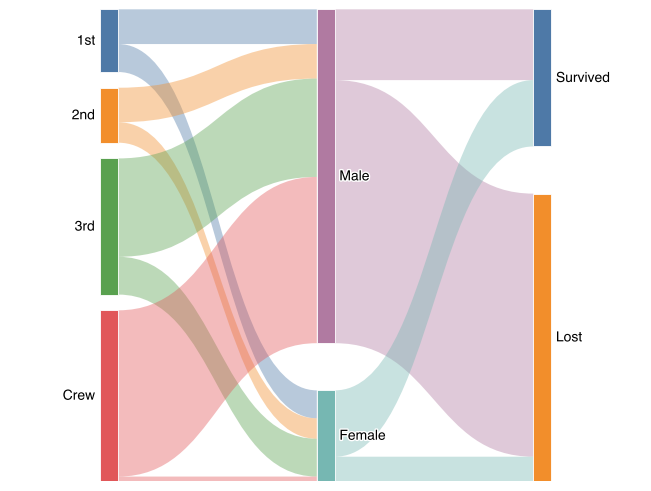

In [4]:
SankeyChart(
    # add the data to the chart
    data=titanic
).show()

## Customizing the Sankey Chart

Every customization is either a keyword argument of `SankeyChart` or a `plot_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title                                 | `title`                                                                 | [Title and figure size](#title-and-figure-size) |
| resize the figure                           | `figsize`                                                               | [Title and figure size](#title-and-figure-size) |
| set the columns or reorder the nodes        | `nodes`                                                                 | [Node columns](#node-columns) |
| head the columns                            | `column_labels`                                                         | [Column labels and ribbon values](#column-labels-and-ribbon-values) |
| write the flow values on the ribbons        | `show_values`, `value_format`                                           | [Column labels and ribbon values](#column-labels-and-ribbon-values) |
| change the node width, gaps, or stroke      | `style={"plot_sankey_node_width": ..., "plot_sankey_node_pad": ...}`    | [Node and ribbon style](#node-and-ribbon-style) |
| color the ribbons by target, or grey them   | `style={"plot_sankey_link_color": "target"}`                            | [Node and ribbon style](#node-and-ribbon-style) |
| drop the halo behind the labels             | `style={"plot_sankey_label_halo_width": 0}`                             | [Node and ribbon style](#node-and-ribbon-style) |
| annotate a point of the chart               | `texts`                                                                 | [Text annotations](#text-annotations) |
| draw several Sankeys side by side           | `subplots`                                                              | [Subplots](#subplots) |
| arrange a Sankey next to other charts       | `Grid`                                                                  | [Composing Sankeys](#composing-sankeys) |

### Title and figure size

To add the chart title, add the `title` attribute. A Sankey has no axes, so there are no axis labels to set. To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains predefined figure sizes.

In [5]:
from datachart.constants import FIG_SIZE

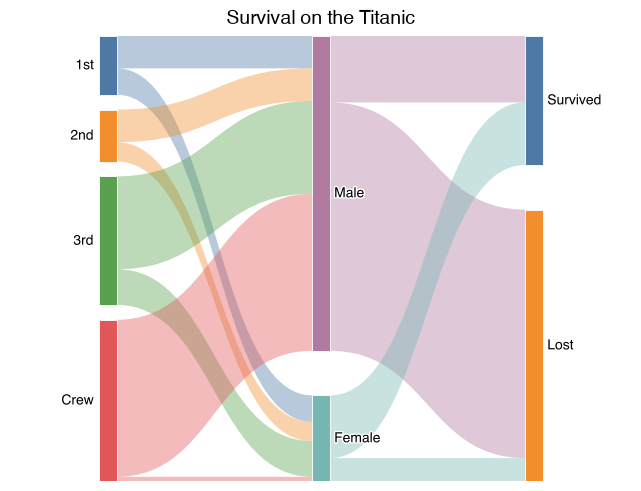

In [6]:
SankeyChart(
    data=titanic,
    # add the title
    title="Survival on the Titanic",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Node columns

By default a node's column is its longest path from any source, and a node that stops early — a leaf reached in one hop — stays in the column it was reached in rather than being pushed to the right edge. To set the columns yourself, add the `nodes` attribute: a list of columns, left to right, each a list of node names top to bottom. It must name every node in the links exactly once, and it also fixes the vertical order, so it is the way to sort the nodes. The example puts the women above the men and the survivors above the lost, so the largest flows cross the least.

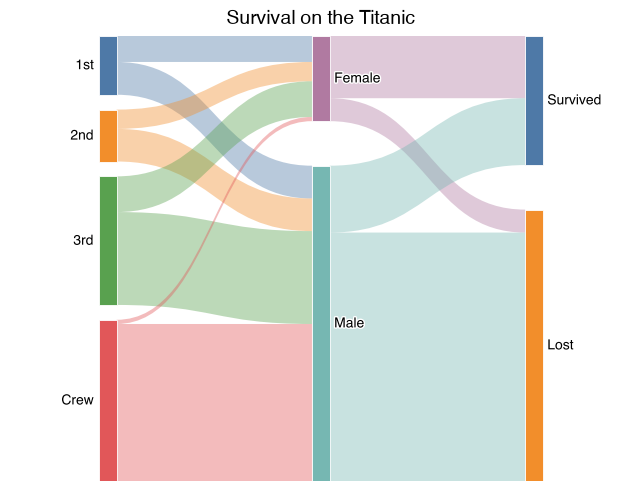

In [7]:
SankeyChart(
    data=titanic,
    # three columns; the order within each is top to bottom
    nodes=[
        ["1st", "2nd", "3rd", "Crew"],
        ["Female", "Male"],
        ["Survived", "Lost"],
    ],
    title="Survival on the Titanic",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Column labels and ribbon values

To head the columns, add the `column_labels` attribute with one label per column, left to right; the headings sit above the columns in the subtitle style. To write each flow's value on its ribbon, add the `show_values` attribute; the `value_format` attribute formats the values and supports the values of the [datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"`, `"{:.1f}%"`, or `"%g"` style string. The values sit at the ribbon midpoints behind the same halo as the labels; thin ribbons get a value all the same, so keep the format short.

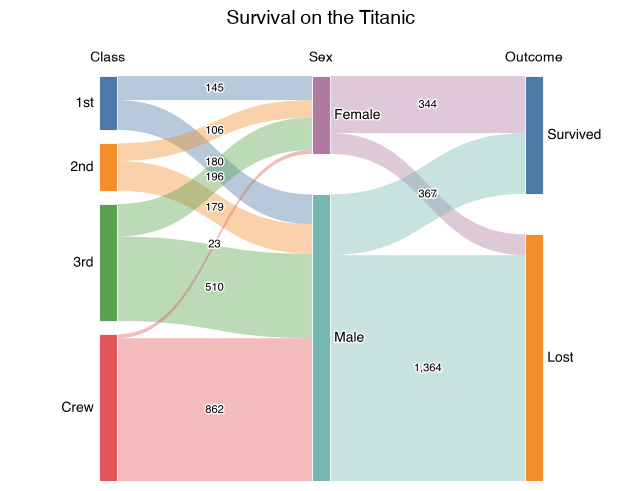

In [8]:
SankeyChart(
    data=titanic,
    nodes=[["1st", "2nd", "3rd", "Crew"], ["Female", "Male"], ["Survived", "Lost"]],
    # head the three columns
    column_labels=["Class", "Sex", "Outcome"],
    # write the counts on the ribbons
    show_values=True,
    value_format="{x:,.0f}",
    title="Survival on the Titanic",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Node and ribbon style

To change the node and ribbon style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.SankeyStyleAttrs](../../../references/typings/#datachart.typings.SankeyStyleAttrs) typing. `plot_sankey_node_width` is the width of the node bars and `plot_sankey_node_pad` the vertical room shared by the gaps of the tallest column, both as fractions of the drawing; `plot_sankey_node_edge_color` and `plot_sankey_node_edge_width` draw the stroke around every node. `plot_sankey_link_color` picks which node colors a ribbon: `"source"` (the default) traces where a flow comes from, `"target"` where it goes, and `"grey"` keeps the ribbons neutral so only the nodes carry color; `plot_sankey_link_alpha` is the ribbon alpha. The labels sit over the ribbons behind a white halo of `plot_sankey_label_halo_width`; set it to `0` to drop the halo.

The example colors the ribbons by their target, so the two outcomes read across the whole chart, and widens the nodes.

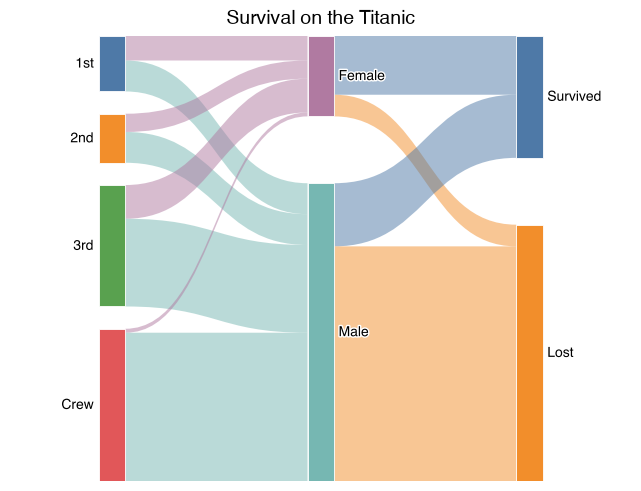

In [9]:
SankeyChart(
    data=titanic,
    nodes=[["1st", "2nd", "3rd", "Crew"], ["Female", "Male"], ["Survived", "Lost"]],
    # ribbons in the color of the node they enter
    style={
        "plot_sankey_link_color": "target",
        "plot_sankey_link_alpha": 0.5,
        "plot_sankey_node_width": 0.06,
        "plot_sankey_node_pad": 0.15,
    },
    title="Survival on the Titanic",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Text annotations

To place text on the chart, add the `texts` attribute with the [datachart.typings.TextAttrs](../../../references/typings/#datachart.typings.TextAttrs) typing. Each annotation sets its `text` and position; the Sankey spans `0`–`1` on both axes, with the columns spread across the horizontal span and the tallest column filling the vertical one, so axes fractions (`"coords": "axes"`) and data coordinates are nearly the same thing. The annotation below states the overall survival rate.

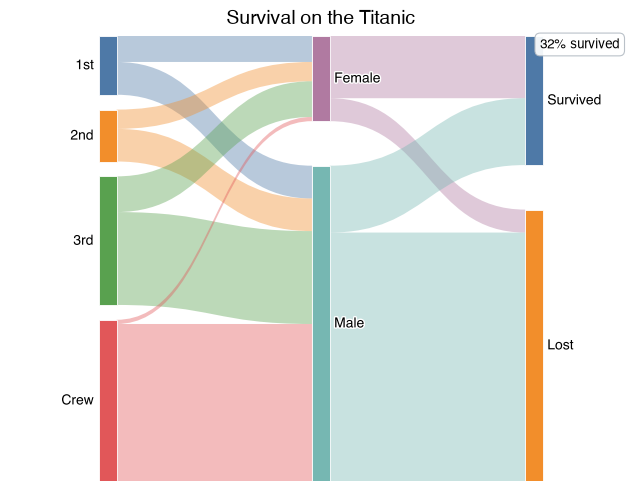

In [10]:
survived = sum(o["Survived"] for o in TITANIC.values())
total = sum(sum(o.values()) for o in TITANIC.values())

SankeyChart(
    data=titanic,
    nodes=[["1st", "2nd", "3rd", "Crew"], ["Female", "Male"], ["Survived", "Lost"]],
    # the overall survival rate, above the right column
    texts={
        "text": f"{100 * survived / total:.0f}% survived",
        "x": 0.98,
        "y": 0.98,
        "coords": "axes",
        "style": {"plot_text_halign": "right"},
    },
    title="Survival on the Titanic",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Sankey Charts

### Subplots

A list of Sankeys draws each in its own subplot; there is no overlay of two Sankeys on one axes, so `subplots` is implied. The `subtitle` becomes the subplot title and the `title` is positioned to be global for all charts. The `max_cols` attribute limits the number of columns. The example splits the flows by sex, so each Sankey shows the classes going straight to their outcome.

In [11]:
by_sex = [
    {
        "links": [
            {"source": cls, "target": outcome, "value": n}
            for (cls, s), outcomes in TITANIC.items()
            if s == sex
            for outcome, n in outcomes.items()
        ]
    }
    for sex in ("Female", "Male")
]

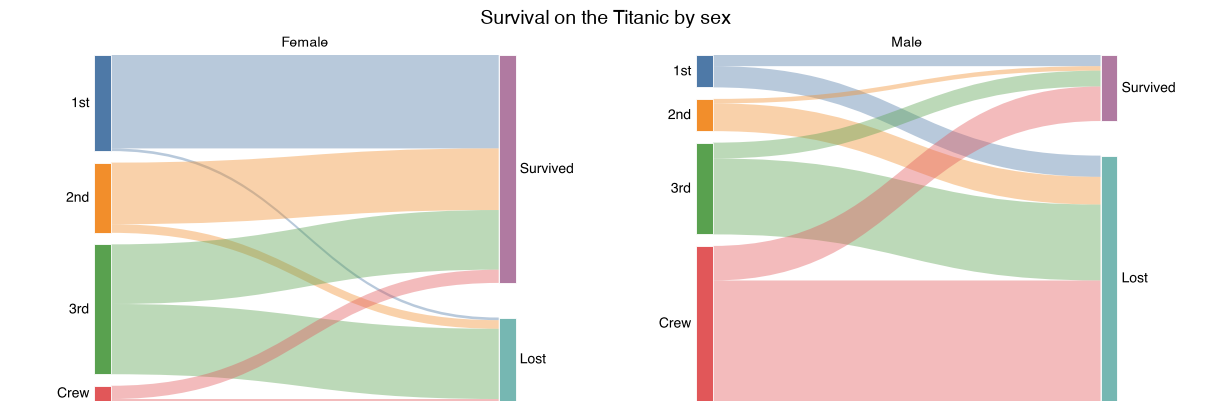

In [12]:
SankeyChart(
    # one Sankey per sex
    data=by_sex,
    subtitle=["Female", "Male"],
    max_cols=2,
    title="Survival on the Titanic by sex",
    figsize=(12, 4),
).show()

### Composing Sankeys

A Sankey owns its axes: there is no shared coordinate space to overlay other charts on, so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a Sankey figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it next to other figures as an ordinary cell. The grid pairs the Sankey with a [datachart.charts.BarChart](../../../references/charts/#datachart.charts.BarChart) of the survival rate per class.

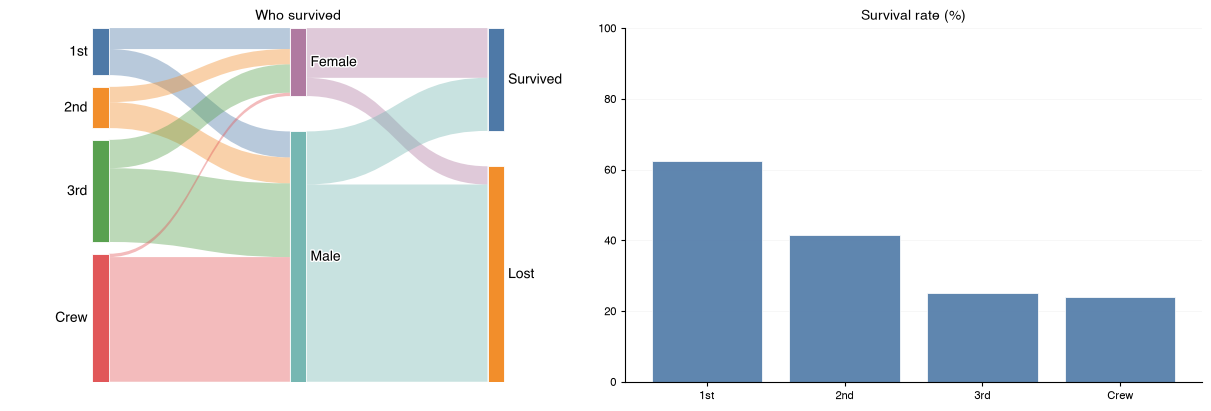

In [13]:
from datachart.charts import BarChart
from datachart.utils import Grid

rates = {}
for (cls, sex), outcomes in TITANIC.items():
    counts = rates.setdefault(cls, [0, 0])
    counts[0] += outcomes["Survived"]
    counts[1] += sum(outcomes.values())

flows = SankeyChart(
    data=titanic,
    nodes=[["1st", "2nd", "3rd", "Crew"], ["Female", "Male"], ["Survived", "Lost"]],
    title="Who survived",
)
rate = BarChart(
    data=[{"label": cls, "y": 100 * s / n} for cls, (s, n) in rates.items()],
    title="Survival rate (%)",
    ymax=100,
)
Grid([[flows, rate]], figsize=(12, 4)).show()

### Themes

A theme sets the palette, the node stroke and the fonts of every chart at once; see the [Theme Gallery](../../styling/theme-gallery.ipynb) for the whole suite under each. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) from the [datachart.constants.THEME](../../../references/constants/#datachart.constants.THEME) constant, and reset the configuration afterwards so the following charts draw in the default again.

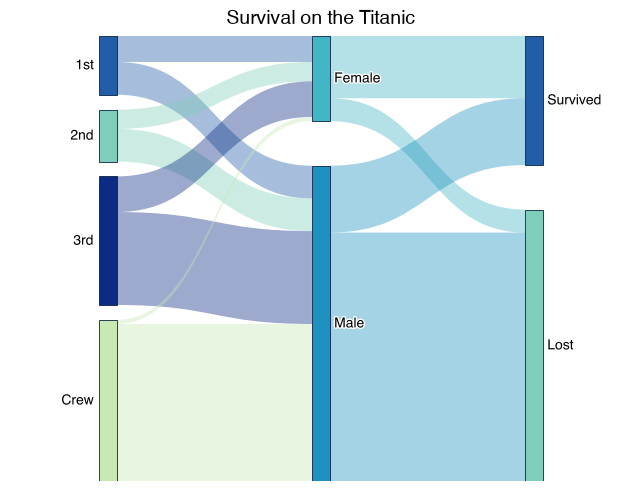

In [14]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.INK)
figure = SankeyChart(
    data=titanic,
    nodes=[["1st", "2nd", "3rd", "Crew"], ["Female", "Male"], ["Survived", "Lost"]],
    title="Survival on the Titanic",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
config.reset_config()
figure.show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [15]:
from datachart.utils import save_figure

figure = SankeyChart(
    data=titanic,
    nodes=[["1st", "2nd", "3rd", "Crew"], ["Female", "Male"], ["Survived", "Lost"]],
    title="Survival on the Titanic",
)
save_figure(figure, "./fig_sankey_chart.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work. Each one states what it shows; any derived data lives in a hidden cell.

### Example 1: Label Agreement Between Annotators (Three Columns and Ribbons by Source)

Two annotators labeled the same 150 sentences as positive, neutral, or negative, and an adjudicator settled the final label. The hidden cell holds the confusion counts. With the ribbons colored by source, the wide straight ribbons are the agreements and the thin crossing ones the disagreements — and the third column shows which annotator the adjudicator sided with.

In [16]:
AGREEMENT = [
    ("pos (A)", "pos (B)", 40), ("pos (A)", "neu (B)", 8), ("pos (A)", "neg (B)", 2),
    ("neu (A)", "neu (B)", 25), ("neu (A)", "pos (B)", 6), ("neu (A)", "neg (B)", 5),
    ("neg (A)", "neg (B)", 30), ("neg (A)", "neu (B)", 4),
    ("pos (B)", "pos", 44), ("pos (B)", "neu", 2),
    ("neu (B)", "neu", 33), ("neu (B)", "pos", 2), ("neu (B)", "neg", 2),
    ("neg (B)", "neg", 35), ("neg (B)", "neu", 2),
]
agreement = {
    "links": [{"source": s, "target": t, "value": v} for s, t, v in AGREEMENT]
}

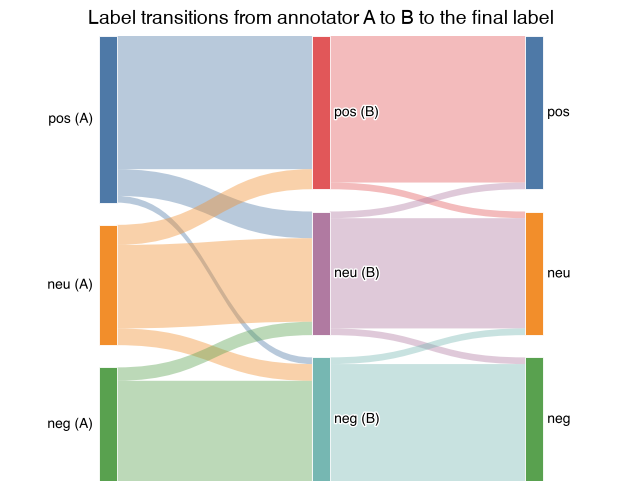

In [17]:
SankeyChart(
    data=agreement,
    title="Label transitions from annotator A to B to the final label",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: A Signup Funnel (Explicit Columns, Grey Ribbons, and an Annotation)

A thousand visitors either bounce or sign up; the signups activate or churn, and the activated ones pay or stay on the free tier. The hidden cell holds the counts. By default each drop-off would sit in the column where it happens; the explicit `nodes` keep that layout but put the drop-offs below the continuing flow at every stage, so the funnel narrows from the top. Grey ribbons leave the color to the nodes, and the annotation states the conversion.

In [18]:
FUNNEL = [
    ("Visited", "Signed up", 300), ("Visited", "Bounced", 700),
    ("Signed up", "Activated", 180), ("Signed up", "Churned", 120),
    ("Activated", "Paid", 90), ("Activated", "Free tier", 90),
]
funnel = {"links": [{"source": s, "target": t, "value": v} for s, t, v in FUNNEL]}

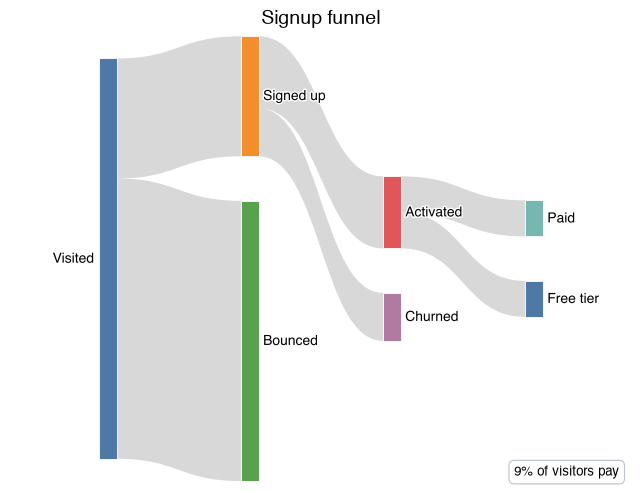

In [19]:
SankeyChart(
    data=funnel,
    nodes=[["Visited"], ["Signed up", "Bounced"], ["Activated", "Churned"], ["Paid", "Free tier"]],
    style={"plot_sankey_link_color": "grey"},
    texts={"text": "9% of visitors pay", "x": 0.98, "y": 0.02, "coords": "axes", "style": {"plot_text_halign": "right"}},
    title="Signup funnel",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()